In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"ankitkkumar12","key":"11c7319dbc78ebc343ba73ec2e6968e5"}'}

In [3]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -o -q 140k-real-and-fake-faces.zip -d faces_data

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
140k-real-and-fake-faces.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import os
print(os.listdir('faces_data'))


['train.csv', 'real_vs_fake', 'valid.csv', 'test.csv']


In [5]:
print(os.listdir('faces_data/real_vs_fake'))

['real-vs-fake']


In [6]:
print(os.listdir('faces_data/real_vs_fake/real-vs-fake'))


['train', 'test', 'valid']


In [7]:
print(os.listdir('faces_data/real_vs_fake/real-vs-fake/train'))

['real', 'fake']


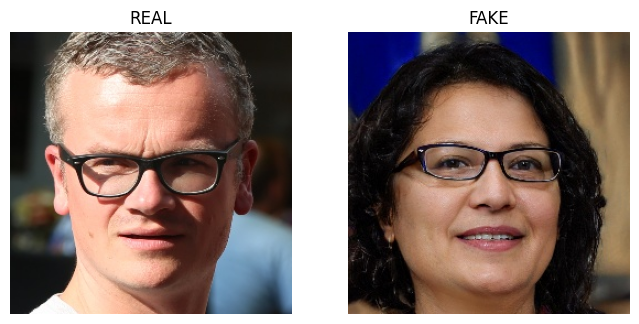

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

real_img = Image.open('faces_data/real_vs_fake/real-vs-fake/train/real/' + os.listdir('faces_data/real_vs_fake/real-vs-fake/train/real')[0])
fake_img = Image.open('faces_data/real_vs_fake/real-vs-fake/train/fake/' + os.listdir('faces_data/real_vs_fake/real-vs-fake/train/fake')[0])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(real_img)
axes[0].set_title('REAL')
axes[0].axis('off')
axes[1].imshow(fake_img)
axes[1].set_title('FAKE')
axes[1].axis('off')
plt.show()

In [9]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader


transform = transforms.Compose([
    transforms.Resize((128, 128)),   # shrink all images to same size
    transforms.ToTensor(),           # convert image to numbers (tensor)
])

# Point to our folders
train_dir = 'faces_data/real_vs_fake/real-vs-fake/train'
valid_dir = 'faces_data/real_vs_fake/real-vs-fake/valid'

train_data = datasets.ImageFolder(train_dir, transform=transform)
valid_data = datasets.ImageFolder(valid_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)

print("Classes:", train_data.classes)
print("Number of training images:", len(train_data))
print("Number of validation images:", len(valid_data))

Classes: ['fake', 'real']
Number of training images: 100000
Number of validation images: 20000


In [10]:
import torch.nn as nn
from torchvision import models

# Load a pretrained model (already knows how to "see" general patterns)
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Replace its final layer so it outputs just 2 classes: real or fake
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

# Move model to GPU (if available) for faster training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Model loaded successfully")
print("Using device:", device)

Model loaded successfully
Using device: cuda


In [11]:
import torch.optim as optim

# Loss function: measures how "wrong" the model's predictions are
criterion = nn.CrossEntropyLoss()

# Optimizer: the algorithm that actually updates the model to reduce that wrongness
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Loss function and optimizer ready")

Loss function and optimizer ready


In [12]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader):.4f} - Train Accuracy: {epoch_acc:.2f}%")

Epoch 1/3 - Loss: 0.1864 - Train Accuracy: 92.09%
Epoch 2/3 - Loss: 0.0529 - Train Accuracy: 98.13%
Epoch 3/3 - Loss: 0.0283 - Train Accuracy: 99.00%


In [13]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

valid_acc = 100 * correct / total
print(f"Validation Accuracy: {valid_acc:.2f}%")

Validation Accuracy: 99.00%


In [14]:
torch.save(model.state_dict(), '/content/drive/MyDrive/deepfake_model.pth')
print("Model saved to Google Drive successfully!")

Model saved to Google Drive successfully!


Saving photo.png to photo (1).png
Prediction: REAL
Confidence: 100.00%


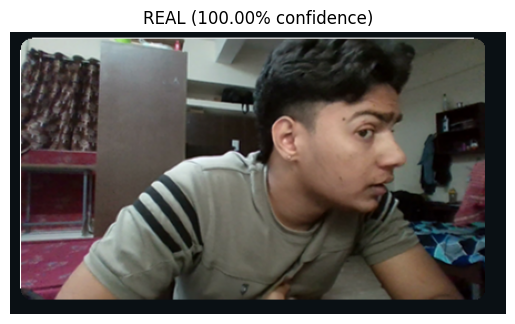

In [15]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

img_path = list(uploaded.keys())[0]
img = Image.open(img_path).convert('RGB')

img_tensor = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probs, 1)

classes = train_data.classes
label = classes[predicted.item()]

print(f"Prediction: {label.upper()}")
print(f"Confidence: {confidence.item()*100:.2f}%")

plt.imshow(img)
plt.title(f"{label.upper()} ({confidence.item()*100:.2f}% confidence)")
plt.axis('off')
plt.show()

In [20]:
!kaggle datasets download -d alessandrasala79/ai-vs-human-generated-dataset
!unzip -o -q ai-vs-human-generated-dataset.zip -d ai_human_data

Dataset URL: https://www.kaggle.com/datasets/alessandrasala79/ai-vs-human-generated-dataset
License(s): apache-2.0
ai-vs-human-generated-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [17]:
print(os.listdir('ai_human_data'))

['test_data_v2', 'train.csv', 'train_data', 'test.csv']


In [18]:
print(os.listdir('ai_human_data/train_data')[:10])


['0bccedf6e22f4e89bed8475d242cf146.jpg', 'cba0fb9656a7426cb46a84690ea84fc0.jpg', 'd77d0eccd1204ee1808050becebce4f5.jpg', 'e81e0818ae8042e2896b0b7f88d495a5.jpg', '9ee5d560f90248debde894e0355661c2.jpg', '2d6bf1e13c5340e0ba2d1a15dee8625f.jpg', '02b0ed80f12c409e918d8305a88114dc.jpg', 'a0972226f0c44f06b9e73339ebea575f.jpg', '62f71d34ed4a40a4a8df83ad97905443.jpg', '35d06a5c7606490a92952346f583e29c.jpg']


In [19]:
import pandas as pd
train_labels = pd.read_csv('ai_human_data/train.csv')
print(train_labels.head())
print(train_labels.shape)

   Unnamed: 0                                        file_name  label
0           0  train_data/a6dcb93f596a43249135678dfcfc17ea.jpg      1
1           1  train_data/041be3153810433ab146bc97d5af505c.jpg      0
2           2  train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg      1
3           3  train_data/8542fe161d9147be8e835e50c0de39cd.jpg      0
4           4  train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg      1
(79950, 3)


label
1    39975
0    39975
Name: count, dtype: int64


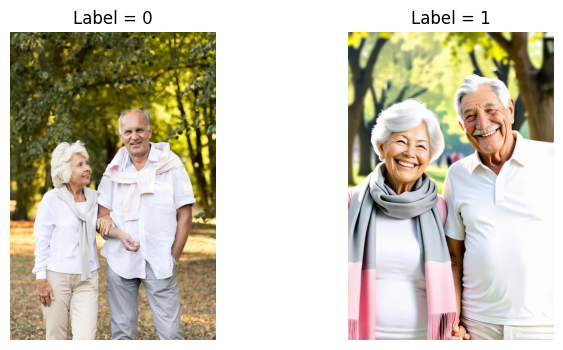

In [21]:
# Check label distribution
print(train_labels['label'].value_counts())

# Show one example of each label
sample_0 = train_labels[train_labels['label'] == 0].iloc[0]
sample_1 = train_labels[train_labels['label'] == 1].iloc[0]

img_0 = Image.open('ai_human_data/' + sample_0['file_name'])
img_1 = Image.open('ai_human_data/' + sample_1['file_name'])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_0)
axes[0].set_title('Label = 0')
axes[0].axis('off')
axes[1].imshow(img_1)
axes[1].set_title('Label = 1')
axes[1].axis('off')
plt.show()

In [22]:
from torch.utils.data import Dataset, ConcatDataset

# Custom dataset class for the CSV-labeled dataset
class AIHumanDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = self.root_dir + '/' + row['file_name']
        image = Image.open(img_path).convert('RGB')
        # Map: 0=human(real)->1, 1=AI(fake)->0  (matching our first dataset's ['fake','real'] order)
        label = 1 if row['label'] == 0 else 0
        if self.transform:
            image = self.transform(image)
        return image, label

# Load second dataset using our existing transform
dataset2 = AIHumanDataset('ai_human_data/train.csv', 'ai_human_data', transform=transform)

# Combine both datasets
combined_train_data = ConcatDataset([train_data, dataset2])
combined_train_loader = DataLoader(combined_train_data, batch_size=32, shuffle=True)

print(f"Dataset 1 (faces): {len(train_data)} images")
print(f"Dataset 2 (AI vs human): {len(dataset2)} images")
print(f"Combined total: {len(combined_train_data)} images")

Dataset 1 (faces): 100000 images
Dataset 2 (AI vs human): 79950 images
Combined total: 179950 images


In [24]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in combined_train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(combined_train_loader):.4f} - Train Accuracy: {epoch_acc:.2f}%")

Epoch 1/3 - Loss: 0.0190 - Train Accuracy: 99.34%
Epoch 2/3 - Loss: 0.0140 - Train Accuracy: 99.52%
Epoch 3/3 - Loss: 0.0124 - Train Accuracy: 99.56%


In [25]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in valid_loader:  # our original 20k face validation set
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

valid_acc = 100 * correct / total
print(f"Validation Accuracy (original faces dataset): {valid_acc:.2f}%")

Validation Accuracy (original faces dataset): 99.22%


In [26]:
torch.save(model.state_dict(), '/content/drive/MyDrive/deepfake_model_v2.pth')
print("Improved model (v2) saved to Google Drive successfully!")

Improved model (v2) saved to Google Drive successfully!


Saving cheeck1.jpg to cheeck1.jpg
Prediction: FAKE
Confidence: 100.00%


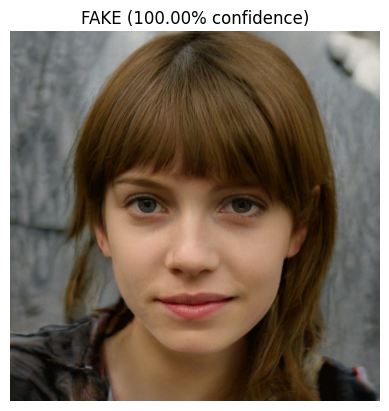

In [27]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

img_path = list(uploaded.keys())[0]
img = Image.open(img_path).convert('RGB')

img_tensor = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probs, 1)

classes = train_data.classes
label = classes[predicted.item()]

print(f"Prediction: {label.upper()}")
print(f"Confidence: {confidence.item()*100:.2f}%")

plt.imshow(img)
plt.title(f"{label.upper()} ({confidence.item()*100:.2f}% confidence)")
plt.axis('off')
plt.show()

Saving 3.webp to 3.webp
Prediction: REAL
Confidence: 100.00%


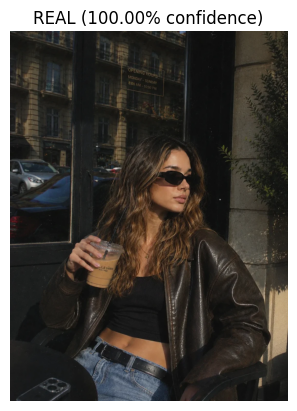

In [31]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

img_path = list(uploaded.keys())[0]
img = Image.open(img_path).convert('RGB')

img_tensor = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probs, 1)

classes = train_data.classes
label = classes[predicted.item()]

print(f"Prediction: {label.upper()}")
print(f"Confidence: {confidence.item()*100:.2f}%")

plt.imshow(img)
plt.title(f"{label.upper()} ({confidence.item()*100:.2f}% confidence)")
plt.axis('off')
plt.show()

In [32]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


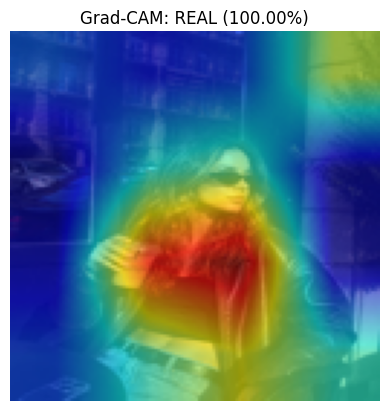

In [34]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

# Target the last convolutional layer of EfficientNet
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Use the same uploaded image from before
img_resized = img.resize((128, 128))
img_np = np.array(img_resized) / 255.0

from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

targets = [ClassifierOutputTarget(predicted.item())]
grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title(f"Grad-CAM: {label.upper()} ({confidence.item()*100:.2f}%)")
plt.axis('off')
plt.show()

In [35]:
!pip install gradio -q

In [37]:
import gradio as gr

def classify_image(input_img):
    img = input_img.convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    label = train_data.classes[predicted.item()]
    emoji = "✅" if label == "real" else "⚠️"
    color = "green" if label == "real" else "red"
    return f"{emoji} **{label.upper()}**\n\nConfidence: **{confidence.item()*100:.2f}%**"

custom_css = """
.gradio-container {
    background: linear-gradient(135deg, #0f0c29, #302b63, #24243e) !important;
}
h1, h2, h3, p, label {
    color: #ffffff !important;
}
.gr-button {
    background: linear-gradient(90deg, #00c6ff, #0072ff) !important;
    color: white !important;
    border: none !important;
    font-weight: bold !important;
}
"""

demo = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil", label="📤 Upload a Face Photo"),
    outputs=gr.Markdown(label="🔍 Result"),
    title="🕵️ AI Deepfake & Synthetic Image Detector",
    description="### Upload any photo — our AI model checks if it's a **REAL** photograph or an **AI-generated / Deepfake** image.\n\nPowered by EfficientNet + Transfer Learning",
    theme=gr.themes.Soft(primary_hue="cyan", secondary_hue="purple"),
    css=custom_css
)

demo.launch(share=True)

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bcce4125161f148a59.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
